# Setup
Imports, seeds, output dirs.

In [1]:
import os
import math
import random
import numpy as np
from pathlib import Path
from collections import deque
from tqdm.auto import tqdm

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import expit, logsumexp

# Set up output directory
OUTPUT_DIR = Path("perfect_plots")
OUTPUT_DIR.mkdir(exist_ok=True)

# Set random seeds for reproducibility
def set_seed(seed=1234):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(1234)


/home/vishnu/miniforge3/envs/rl_test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config
Hyperparameters and configuration definitions.

In [2]:
HYPERPARAMS = {
    # Shared / env
    "num_episodes": 1000,  
    "max_steps": 200,
    # "goal_switch_episode": 500,  # replaced by joint 50-episode mastery trigger
    "initial_goal": (0, 10),
    "switched_goal": (10, 10),
    "n_runs": 1,

    # Eigenoptions
    "gamma": 0.9,
    "alpha": 0.1,
    "epsilon_start": 1.0,
    "epsilon_min": 0.02,
    "num_options_to_use": 64,
    "epsilon_boost_after_switch": 0.5,

    # Deep Successor Representation 
    # "sr_latent_dim": 32,
    # "sr_encoder_hidden": 64,
    # "sr_lr": 1e-3,
    "sr_gamma": 0.9,            
    # "sr_replay_size": 20_000,
    # "sr_train_steps": 10_000,
    # "sr_batch_size": 64,
    # "sr_target_update_freq": 200,
    # "sr_recon_weight": 1.0,

    # Eigenpurpose extraction
    # "eigen_rollout_steps": 5_000,
    "eigenpurpose_k": 32,        
    "first_eigenoption": 1,     

    # Intrinsic-reward eigenoption training (unused; options are solved by planning here)
    # "intrinsic_train_steps": 50_000,
    # "intrinsic_lr": 1e-3,
    # "intrinsic_epsilon_start": 1.0,
    # "intrinsic_epsilon_min": 0.05,

    # Neural Option-Critic Network
    "nn_oc_noptions": 4,
    "nn_oc_discount": 0.99,
    "nn_oc_lr_term": 1e-4,
    "nn_oc_lr_intra": 1e-3,
    "nn_oc_lr_critic": 2e-3,
    "nn_oc_epsilon": 0.1,
    "nn_oc_temperature": 1.0,
    "nn_oc_action_epsilon": 0.02,
    "nn_oc_action_epsilon_after_switch": 0.15,
    "nn_oc_entropy_coef": 0.01,
    "nn_oc_update_epochs": 2,
    "nn_oc_target_update_freq": 10,
    "nn_oc_replay_size": 20_000,
    "nn_oc_batch_size": 64,
    "nn_oc_min_actor_successes": 0,

    # Snapshots & evaluation
    "snapshot_early_offset": 200,
    "snapshot_mid_offset": 500,
    # "phase_window": 100,
    "deliberation_cost": 0.02,
}


# Environment
Gridworld environment definition and views. No training logic here.

In [3]:
class FourRoomsEnv(gym.Env):
    """11x11 Four Rooms gridworld environment with doorway bottlenecks."""
    def __init__(self, bottleneck_rewards=False, goal_state=(0, 10)):
        super().__init__()
        self.grid_size = 11
        self.max_steps = 200
        self.bottleneck_rewards = bottleneck_rewards
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(
            low=0.0, high=float(self.grid_size), shape=(6,), dtype=np.float32,
        )
        self.goal_state = goal_state
        self.walls = set()
        for i in range(self.grid_size):
            self.walls.add((5, i))
            self.walls.add((i, 5))
        self.doorway_list = [(5, 1), (5, 8), (2, 5), (9, 5)]
        for doorway in self.doorway_list:
            self.walls.remove(doorway)
        self.valid_states = []
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) not in self.walls:
                    self.valid_states.append((r, c))
        self.state_to_idx = {state: idx for idx, state in enumerate(self.valid_states)}
        self.idx_to_state = {idx: state for state, idx in self.state_to_idx.items()}
        self.num_states = len(self.valid_states)
        self.current_state = None
        self.current_step = 0
        self.visited_doorways = set()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.visited_doorways.clear()
        idx = self.np_random.integers(0, len(self.valid_states))
        while self.valid_states[idx] == self.goal_state:
            idx = self.np_random.integers(0, len(self.valid_states))
        self.current_state = self.valid_states[idx]
        return self._get_obs(), {}

    def step(self, action):
        action = int(action)
        self.current_step += 1
        r, c = self.current_state
        if action == 0: r -= 1
        elif action == 1: c += 1
        elif action == 2: r += 1
        elif action == 3: c -= 1
        if (0 <= r < self.grid_size and 0 <= c < self.grid_size and (r, c) not in self.walls):
            self.current_state = (r, c)
        terminated = self.current_state == self.goal_state
        truncated = self.current_step >= self.max_steps
        reward = 1.0 if terminated else 0.0
        if (self.bottleneck_rewards and self.current_state in self.doorway_list
                and self.current_state not in self.visited_doorways):
            reward += 0.5
            self.visited_doorways.add(self.current_state)
        return self._get_obs(), reward, terminated, truncated, {}

    def _get_obs(self):
        r, c = self.current_state
        obs = [float(r), float(c)]
        for doorway in self.doorway_list:
            obs.append(1.0 if doorway in self.visited_doorways else 0.0)
        return np.array(obs, dtype=np.float32)

    def get_state_idx(self):
        return self.state_to_idx[self.current_state]

class PolicyIterationView:
    """Read-only adapter exposing goal-free grid dynamics for eigenpurpose planning."""
    def __init__(self, env, terminal_states=None):
        self._env = env
        self.num_states = env.num_states
        self.action_set = [0, 1, 2, 3]
        self.reward_function = None
        self.terminal_states = set(terminal_states or [])

    def define_reward_function(self, vector):
        self.reward_function = vector

    def get_action_set(self):
        return self.action_set
        
    def get_next_state_and_reward(self, s_idx, a):
        if s_idx == self.num_states:
            return s_idx, 0.0
        if a == 4 or self._env.idx_to_state[s_idx] in self.terminal_states:
            return self.num_states, 0.0

        r, c = self._env.idx_to_state[s_idx]
        nr, nc = r, c
        if a == 0: nr -= 1
        elif a == 1: nc += 1
        elif a == 2: nr += 1
        elif a == 3: nc -= 1
        if (0 <= nr < self._env.grid_size and 0 <= nc < self._env.grid_size and (nr, nc) not in self._env.walls):
            next_s_idx = self._env.state_to_idx[(nr, nc)]
        else:
            next_s_idx = s_idx

        reward = 0.0
        if self.reward_function is not None:
            reward = self.reward_function[next_s_idx] - self.reward_function[s_idx]
        return next_s_idx, reward


# Models
Policy Iteration, Eigenoptions, and Option-Critic architectures.

In [4]:
class PolicyIteration:
    """Solves for an optimal policy given an environment view with known dynamics."""
    def __init__(self, gamma, env_view, augment_action_set=False):
        self.gamma = gamma
        self.env_view = env_view
        self.num_states = env_view.num_states + 1

        self.values = np.zeros(self.num_states)
        self.policy = np.zeros(self.num_states, dtype=np.int64)

        if augment_action_set:
            self.action_set = np.append(env_view.get_action_set(), [4])
        else:
            self.action_set = env_view.get_action_set()

    def _eval_policy(self):
        delta = 0.0
        for s in range(self.num_states - 1): # Ignore absorbing state in eval
            v = self.values[s]
            next_s, next_r = self.env_view.get_next_state_and_reward(s, self.policy[s])
            self.values[s] = next_r + self.gamma * self.values[next_s]
            delta = max(delta, math.fabs(v - self.values[s]))
        return delta

    def _improve_policy(self):
        policy_stable = True
        for s in range(self.num_states - 1):
            old_action = self.policy[s]
            temp_v = [0.0] * len(self.action_set)
            for i, action in enumerate(self.action_set):
                next_s, next_r = self.env_view.get_next_state_and_reward(s, action)
                temp_v[i] = next_r + self.gamma * self.values[next_s]

            best_action_idx = int(np.argmax(temp_v))
            self.policy[s] = int(self.action_set[best_action_idx])
            if 4 in self.action_set:
                term_idx = int(np.where(self.action_set == 4)[0][0])
                if math.fabs(temp_v[best_action_idx] - temp_v[term_idx]) < 0.001:
                    self.policy[s] = 4
            if old_action != self.policy[s]:
                policy_stable = False
        return policy_stable

    def solve(self, theta=0.001):
        policy_stable = False
        while not policy_stable:
            delta = self._eval_policy()
            while theta < delta:
                delta = self._eval_policy()
            policy_stable = self._improve_policy()
        return self.values, self.policy

class EigenoptionPolicy:
    """Wrapper for a primitive policy acting as an option."""
    def __init__(self, pi, option_id, eigenvalue):
        self.pi = pi
        self.id = option_id
        self.eigenvalue = eigenvalue

    def act(self, s_idx, env):
        return int(self.pi[s_idx])

    def is_terminal(self, s_idx, env):
        return self.pi[s_idx] == 4

    def can_initiate(self, s_idx, env):
        return self.pi[s_idx] != 4

def build_sr(env, gamma):
    """Task-agnostic SR matrix built from pure grid connectivity."""
    n = env.num_states
    p_mat = np.zeros((n, n))
    for s_idx in tqdm(range(n), desc='Building SR Matrix', leave=False):
        r, c = env.idx_to_state[s_idx]
        for a in range(4):
            nr, nc = r, c
            if a == 0: nr -= 1
            elif a == 1: nc += 1
            elif a == 2: nr += 1
            elif a == 3: nc -= 1
            if (0 <= nr < env.grid_size and 0 <= nc < env.grid_size and (nr, nc) not in env.walls):
                next_idx = env.state_to_idx[(nr, nc)]
            else:
                next_idx = s_idx
            p_mat[s_idx, next_idx] += 0.25
    m_mat = np.linalg.inv(np.eye(n) - gamma * p_mat)
    return m_mat

def decompose_sr(m_mat):
    """Return real SR eigenpairs sorted by descending eigenvalue."""
    if np.allclose(m_mat, m_mat.T, atol=1e-10):
        eigenvalues, eigenvectors_col = np.linalg.eigh(m_mat)
    else:
        eigenvalues, eigenvectors_col = np.linalg.eig(m_mat)

    eigenvalues = np.real_if_close(eigenvalues, tol=1000).real
    eigenvectors = np.real_if_close(eigenvectors_col, tol=1000).real.T

    order = np.argsort(-eigenvalues)
    return eigenvalues[order], eigenvectors[order, :]


def extract_eigenoptions(env, m_mat, gamma, eigenpurpose_k, first_eigenoption,
                         eigenvalues=None, eigenvectors=None):
    """Extract eigenoptions from the SR matrix via right eigenvectors."""
    env_view = PolicyIterationView(env)
    if eigenvalues is None or eigenvectors is None:
        eigenvalues, eigenvectors = decompose_sr(m_mat)

    options_bank = []
    num_to_use = min(eigenpurpose_k, len(eigenvalues) - first_eigenoption)
    epsilon = 0.0001

    for i in tqdm(range(first_eigenoption, first_eigenoption + num_to_use), desc='Building Eigenoptions', leave=False):
        for direction in [1.0, -1.0]:
            e_i = eigenvectors[i] * direction

            pol_iter = PolicyIteration(gamma, env_view, augment_action_set=True)
            env_view.define_reward_function(e_i)
            values, pi = pol_iter.solve()

            for j in range(len(values)):
                if values[j] < epsilon:
                    pi[j] = 4

            opt = EigenoptionPolicy(pi[:env.num_states], len(options_bank), eigenvalues[i])
            options_bank.append(opt)

    return options_bank

class CriticNetwork(nn.Module):
    """Critic network to evaluate Q_Omega(s, omega)."""
    def __init__(self, num_options, grid_size=11):
        super(CriticNetwork, self).__init__()
        self.num_options = num_options
        self.grid_size = grid_size
        self.embedding = nn.Embedding(grid_size * grid_size, 32)
        self.network = nn.Sequential(
            nn.Linear(32 + 4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_options)
        )
        nn.init.zeros_(self.network[-1].weight)
        nn.init.zeros_(self.network[-1].bias)

    def forward(self, state):
        r = state[:, 0]
        c = state[:, 1]
        state_idx = (r * self.grid_size + c).long()
        spatial_emb = self.embedding(state_idx)
        doorways = state[:, 2:]
        x = torch.cat([spatial_emb, doorways], dim=-1)
        return self.network(x)

class ActorNetwork(nn.Module):
    """Two-headed Actor network for intra-option policies and termination functions."""
    def __init__(self, num_actions, num_options, grid_size=11, temperature=1.0, action_epsilon=0.0):
        super(ActorNetwork, self).__init__()
        self.num_actions = num_actions
        self.num_options = num_options
        self.grid_size = grid_size
        self.temperature = max(float(temperature), 1e-6)
        self.action_epsilon = float(np.clip(action_epsilon, 0.0, 1.0))
        self.embedding = nn.Embedding(grid_size * grid_size, 32)
        self.backbone = nn.Sequential(
            nn.Linear(32 + 4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.policy_head = nn.Linear(64, num_options * num_actions)
        self.termination_head = nn.Linear(64, num_options)
        nn.init.constant_(self.termination_head.bias, -1.0)

    def forward(self, state):
        r = state[:, 0]
        c = state[:, 1]
        state_idx = (r * self.grid_size + c).long()
        spatial_emb = self.embedding(state_idx)
        doorways = state[:, 2:]
        x = torch.cat([spatial_emb, doorways], dim=-1)
        features = self.backbone(x)
        policy_logits = self.policy_head(features)
        policy_logits = policy_logits.view(-1, self.num_options, self.num_actions)
        action_probs = F.softmax(policy_logits / self.temperature, dim=-1)
        if self.action_epsilon > 0.0:
            uniform = torch.full_like(action_probs, 1.0 / self.num_actions)
            action_probs = (1.0 - self.action_epsilon) * action_probs + self.action_epsilon * uniform
        termination_probs = torch.sigmoid(self.termination_head(features))
        return action_probs, termination_probs

class OptionCriticMath:
    """Helper class containing the option-critic update equations."""
    @staticmethod
    def get_state_value(q_omega):
        return torch.max(q_omega, dim=-1)[0]

    @staticmethod
    def get_arrival_value(q_omega_next, v_state_next, beta_next, current_option):
        batch_size = q_omega_next.size(0)
        batch_idx = torch.arange(batch_size, device=q_omega_next.device)
        q_w_next = q_omega_next[batch_idx, current_option]
        beta_w_next = beta_next[batch_idx, current_option]
        return (1.0 - beta_w_next) * q_w_next + beta_w_next * v_state_next

    @staticmethod
    def get_action_value_in_context(reward, gamma, u_value, done):
        return reward + gamma * u_value * (1.0 - done)

    @staticmethod
    def get_intra_option_advantage(q_u, q_omega, current_option):
        batch_size = q_omega.size(0)
        batch_idx = torch.arange(batch_size, device=q_omega.device)
        q_w = q_omega[batch_idx, current_option]
        return q_u - q_w

    @staticmethod
    def get_termination_advantage(q_omega_next, v_state_next, current_option):
        batch_size = q_omega_next.size(0)
        batch_idx = torch.arange(batch_size, device=q_omega_next.device)
        q_w_next = q_omega_next[batch_idx, current_option]
        return q_w_next - v_state_next

class OptionCriticAgent:
    """Agent class for option selection, primitive-action sampling, and termination sampling."""
    def __init__(self, actor, critic, num_options, num_episodes, epsilon_min=0.10, device='cpu'):
        self.actor = actor.to(device)
        self.critic = critic.to(device)
        self.num_options = num_options
        self.device = device
        self.epsilon = 1.0
        self.epsilon_min = epsilon_min
        self.epsilon_decay = 1.0 / (num_episodes / 2)

    def get_new_option(self, state_tensor):
        if random.random() < self.epsilon:
            return random.randint(0, self.num_options - 1)
        else:
            with torch.no_grad():
                q_values = self.critic(state_tensor.to(self.device))[0]
                max_q = torch.max(q_values)
                best_options = torch.nonzero(torch.isclose(q_values, max_q, atol=1e-6), as_tuple=False).flatten()
                return best_options[torch.randint(len(best_options), (1,))].item()

    def get_action(self, state_tensor, current_option):
        with torch.no_grad():
            action_probs, _ = self.actor(state_tensor.to(self.device))
            opt_probs = action_probs[0, current_option, :]
            dist = Categorical(opt_probs)
            return dist.sample().item()

    def predict_termination(self, state_tensor, current_option):
        with torch.no_grad():
            _, term_probs = self.actor(state_tensor.to(self.device))
            beta = term_probs[0, current_option].item()
            return random.random() < beta

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)


# Training
Training loops for SMDP Q-Learning and Option Critic. Loops take config + model + env as args.

In [5]:
def smdp_q_learning(env, options, num_episodes, max_steps, alpha, gamma, 
                    epsilon_start, epsilon_min, epsilon_boost_after_switch, 
                    switched_goal, snapshot_early_offset, snapshot_mid_offset):
    """Train an agent using SMDP Q-learning with the provided options."""
    num_states = env.num_states
    num_primitive = 4
    total_actions = num_primitive + len(options)

    q_table = np.zeros((num_states, total_actions))
    epsilon = epsilon_start
    epsilon_decay = epsilon_start / (num_episodes / 2)

    goal_switch_episode = None
    goal_switched = False
    
    episode_rewards = []
    episode_steps = []
    episode_success = []
    q_snapshots = {}

    def get_valid_actions(s_idx):
        valid = list(range(num_primitive))
        for opt_idx, opt in enumerate(options):
            if opt.can_initiate(s_idx, env):
                valid.append(num_primitive + opt_idx)
        return valid

    def select_action(s_idx, eps):
        valid_actions = get_valid_actions(s_idx)
        if np.random.rand() < eps:
            return int(np.random.choice(valid_actions))
        q_vals = q_table[s_idx]
        masked = np.full(total_actions, -1e9, dtype=np.float64)
        masked[valid_actions] = q_vals[valid_actions]
        max_q = np.max(masked)
        best_actions = [a for a in valid_actions if masked[a] == max_q]
        return int(np.random.choice(best_actions))

    def best_next_value(s_idx, done):
        if done: return 0.0
        valid_next = get_valid_actions(s_idx)
        return np.max(q_table[s_idx, valid_next])

    switch_triggered = False
    for episode in range(num_episodes):
        if switch_triggered and not goal_switched:
            goal_switch_episode = episode
            q_snapshots["before_switch"] = q_table.copy()
            env.goal_state = switched_goal
            epsilon = max(epsilon, epsilon_boost_after_switch)
            goal_switched = True

        obs, _ = env.reset()
        state_idx = env.get_state_idx()
        total_reward = 0
        step = 0
        reached_goal = False

        while step < max_steps:
            action_idx = select_action(state_idx, epsilon)
            should_break = False

            if action_idx < num_primitive:
                start_state_idx = state_idx
                next_obs, reward, terminated, truncated, _ = env.step(action_idx)
                next_state_idx = env.get_state_idx()
                done = bool(terminated or truncated)

                target = reward + (1.0 - float(done)) * gamma * best_next_value(next_state_idx, done)
                q_table[start_state_idx, action_idx] += alpha * (target - q_table[start_state_idx, action_idx])

                state_idx = next_state_idx
                total_reward += reward
                step += 1

                if terminated: reached_goal = True
                if terminated or truncated: should_break = True
            else:
                option_idx = action_idx - num_primitive
                option = options[option_idx]
                start_state_idx = state_idx

                k = 0
                option_reward = 0.0
                terminated, truncated = False, False

                while True:
                    if option.is_terminal(state_idx, env): break
                    primitive_action = option.act(state_idx, env)
                    next_obs, reward, terminated, truncated, _ = env.step(primitive_action)
                    next_state_idx = env.get_state_idx()

                    option_reward += (gamma ** k) * reward
                    k += 1
                    state_idx = next_state_idx
                    total_reward += reward
                    step += 1

                    if terminated: reached_goal = True
                    if terminated or truncated or step >= max_steps: break

                done = bool(terminated or truncated)
                target = option_reward + (1.0 - float(done)) * (gamma ** k) * best_next_value(state_idx, done)
                q_table[start_state_idx, action_idx] += alpha * (target - q_table[start_state_idx, action_idx])

                if terminated or truncated: should_break = True

            if should_break: break

        epsilon = max(epsilon_min, epsilon - epsilon_decay)
        episode_rewards.append(total_reward)
        episode_steps.append(step)
        episode_success.append(1.0 if reached_goal else 0.0)

        if goal_switch_episode is not None and goal_switched:
            if episode == goal_switch_episode + snapshot_early_offset:
                q_snapshots["early_adaptation"] = q_table.copy()
            elif episode == goal_switch_episode + snapshot_mid_offset:
                q_snapshots["mid_adaptation"] = q_table.copy()

        switch_triggered = yield total_reward

    q_snapshots["final"] = q_table.copy()
    return q_table.copy(), episode_rewards, episode_steps, episode_success, q_snapshots

def _transition_tensors(transitions, device):
    states, options, actions, rewards, next_states, dones = zip(*transitions)
    states_t = torch.FloatTensor(np.array(states)).to(device)
    next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
    options_t = torch.LongTensor(options).to(device)
    actions_t = torch.LongTensor(actions).to(device)
    rewards_t = torch.FloatTensor(rewards).to(device)
    dones_t = torch.FloatTensor(dones).to(device)
    batch_idx = torch.arange(len(transitions), device=device)
    return states_t, options_t, actions_t, rewards_t, next_states_t, dones_t, batch_idx

def update_option_critic(agent, math_helper, actor_opt, critic_opt, target_critic,
                         critic_transitions, actor_transitions, gamma, deliberation_cost,
                         entropy_coef=0.0, update_actor=True):
    """Neural Option-Critic update: replay critic, on-policy actor."""
    if not critic_transitions:
        return

    states_t, options_t, _, rewards_t, next_states_t, dones_t, batch_idx = _transition_tensors(
        critic_transitions, agent.device
    )

    q_omega = agent.critic(states_t)
    q_current = q_omega[batch_idx, options_t]
    with torch.no_grad():
        q_omega_next = target_critic(next_states_t)
        _, term_probs_next = agent.actor(next_states_t)
        v_state_next = math_helper.get_state_value(q_omega_next)
        u_value = math_helper.get_arrival_value(q_omega_next, v_state_next, term_probs_next, options_t)
        td_target = math_helper.get_action_value_in_context(rewards_t, gamma, u_value, dones_t)

    critic_loss = F.mse_loss(q_current, td_target)
    critic_opt.zero_grad()
    critic_loss.backward()
    nn.utils.clip_grad_norm_(agent.critic.parameters(), max_norm=5.0)
    critic_opt.step()

    if not update_actor or not actor_transitions:
        return

    states_t, options_t, actions_t, rewards_t, next_states_t, dones_t, batch_idx = _transition_tensors(
        actor_transitions, agent.device
    )
    with torch.no_grad():
        q_omega = agent.critic(states_t)
        q_omega_next = target_critic(next_states_t)
        _, term_probs_next = agent.actor(next_states_t)
        v_state_next = math_helper.get_state_value(q_omega_next)
        u_value = math_helper.get_arrival_value(q_omega_next, v_state_next, term_probs_next, options_t)
        td_target = math_helper.get_action_value_in_context(rewards_t, gamma, u_value, dones_t)

    with torch.no_grad():
        q_omega_detached = q_omega.detach()
        intra_adv = td_target - q_omega_detached[batch_idx, options_t]
        q_omega_next_for_term = target_critic(next_states_t)
        v_state_next_for_term = math_helper.get_state_value(q_omega_next_for_term)
        term_adv = math_helper.get_termination_advantage(q_omega_next_for_term, v_state_next_for_term, options_t)

    action_probs, _ = agent.actor(states_t)
    dist = Categorical(action_probs[batch_idx, options_t, :])
    actor_loss = -(dist.log_prob(actions_t) * intra_adv).mean()
    actor_loss = actor_loss - entropy_coef * dist.entropy().mean()

    _, term_probs_next_grad = agent.actor(next_states_t)
    beta_next = term_probs_next_grad[batch_idx, options_t]
    termination_loss = ((1.0 - dones_t) * beta_next * (term_adv + deliberation_cost)).mean()

    actor_opt.zero_grad()
    (actor_loss + termination_loss).backward()
    nn.utils.clip_grad_norm_(agent.actor.parameters(), max_norm=5.0)
    actor_opt.step()

def net_to_qtable(critic_net, env, device):
    """Evaluate the critic network on all valid states (batched)."""
    obs_batch = np.zeros((env.num_states, 6), dtype=np.float32)
    for s_idx in range(env.num_states):
        r, c = env.idx_to_state[s_idx]
        obs_batch[s_idx] = [float(r), float(c), 0.0, 0.0, 0.0, 0.0]
    
    with torch.no_grad():
        table = critic_net(torch.from_numpy(obs_batch).to(device)).cpu().numpy()
    return table

def train_nn_oc(env, num_episodes, max_steps, nn_oc_noptions, nn_oc_discount, deliberation_cost, 
                switched_goal, epsilon_boost_after_switch, snapshot_early_offset, snapshot_mid_offset,
                critic_lr, actor_lr, termination_lr, epsilon_min, temperature,
                action_epsilon, action_epsilon_after_switch, entropy_coef, update_epochs, target_update_freq,
                replay_size, batch_size, min_actor_successes):
    """Train the Option-Critic agent."""
    device = torch.device('cpu')

    actor = ActorNetwork(env.action_space.n, nn_oc_noptions, grid_size=env.grid_size,
                         temperature=temperature, action_epsilon=action_epsilon)
    critic = CriticNetwork(nn_oc_noptions, grid_size=env.grid_size)
    target_critic = CriticNetwork(nn_oc_noptions, grid_size=env.grid_size)
    target_critic.load_state_dict(critic.state_dict())
    target_critic.eval()

    critic_opt = optim.Adam(critic.parameters(), lr=critic_lr)
    actor_opt = optim.Adam([
        {'params': actor.embedding.parameters(), 'lr': actor_lr},
        {'params': actor.backbone.parameters(), 'lr': actor_lr},
        {'params': actor.policy_head.parameters(), 'lr': actor_lr},
        {'params': actor.termination_head.parameters(), 'lr': termination_lr}
    ])

    math_helper = OptionCriticMath()
    agent = OptionCriticAgent(actor, critic, nn_oc_noptions, num_episodes,
                              epsilon_min=epsilon_min, device=device)

    episode_rewards = []
    episode_steps = []
    episode_success = []
    q_snapshots = {}
    successful_episodes_seen = 0
    replay_buffer = deque(maxlen=replay_size)

    goal_switch_episode = None
    goal_switched = False
    switch_triggered = False

    for episode in range(num_episodes):
        if switch_triggered and not goal_switched:
            goal_switch_episode = episode
            q_snapshots["before_switch"] = net_to_qtable(critic, env, device)
            env.goal_state = switched_goal
            replay_buffer.clear()
            nn.init.zeros_(critic.network[-1].weight)
            nn.init.zeros_(critic.network[-1].bias)
            target_critic.load_state_dict(critic.state_dict())
            critic_opt = optim.Adam(critic.parameters(), lr=critic_lr)
            actor.action_epsilon = max(actor.action_epsilon, action_epsilon_after_switch)
            agent.epsilon = max(agent.epsilon, epsilon_boost_after_switch)
            goal_switched = True

        state_numpy, _ = env.reset()
        state_tensor = torch.FloatTensor(state_numpy).unsqueeze(0)
        current_option = agent.get_new_option(state_tensor)

        total_reward = 0
        step = 0
        reached_goal = False
        episode_transitions = []

        while step < max_steps:
            action = agent.get_action(state_tensor, current_option)
            next_state_numpy, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state_tensor = torch.FloatTensor(next_state_numpy).unsqueeze(0)

            episode_transitions.append((state_numpy, current_option, action, reward, next_state_numpy, float(done)))
            total_reward += reward
            step += 1

            if terminated: reached_goal = True
            if terminated or truncated: break

            option_terminates = agent.predict_termination(next_state_tensor, current_option)
            if option_terminates:
                current_option = agent.get_new_option(next_state_tensor)

            state_numpy = next_state_numpy
            state_tensor = next_state_tensor

        if reached_goal:
            successful_episodes_seen += 1
        replay_buffer.extend(episode_transitions)
        update_actor = successful_episodes_seen >= min_actor_successes
        for _ in range(update_epochs):
            if len(replay_buffer) > batch_size:
                critic_batch = random.sample(replay_buffer, batch_size)
            else:
                critic_batch = list(replay_buffer)
            update_option_critic(
                agent, math_helper, actor_opt, critic_opt, target_critic,
                critic_batch, episode_transitions,
                gamma=nn_oc_discount, deliberation_cost=deliberation_cost,
                entropy_coef=entropy_coef, update_actor=update_actor,
            )
        if (episode + 1) % target_update_freq == 0:
            target_critic.load_state_dict(critic.state_dict())

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_steps.append(step)
        episode_success.append(1.0 if reached_goal else 0.0)

        if goal_switch_episode is not None and goal_switched:
            if episode == goal_switch_episode + snapshot_early_offset:
                q_snapshots["early_adaptation"] = net_to_qtable(critic, env, device)
            elif episode == goal_switch_episode + snapshot_mid_offset:
                q_snapshots["mid_adaptation"] = net_to_qtable(critic, env, device)

        switch_triggered = yield total_reward

    q_snapshots["final"] = net_to_qtable(critic, env, device)
    return episode_rewards, episode_steps, episode_success, q_snapshots, agent, actor, critic

def run_experiments(hyperparams):
    n_runs = hyperparams["n_runs"]
    num_episodes = hyperparams["num_episodes"]
    
    results = {
        "eo_rewards": [], "eo_steps": [], "eo_success": [], "eo_snapshots": [],
        "nn_oc_rewards": [], "nn_oc_steps": [], "nn_oc_success": [], "nn_oc_snapshots": [],
        "switch_episodes": []
    }
    
    for run in range(n_runs):
        print(f"--- Joint Run {run+1}/{n_runs} ---")
        env_eo = FourRoomsEnv(goal_state=hyperparams["initial_goal"])
        env_nn_oc = FourRoomsEnv(goal_state=hyperparams["initial_goal"])
        
        # Build SR and Eigenoptions
        m_sr = build_sr(env_eo, hyperparams["sr_gamma"])
        sr_eigenvalues, sr_eigenvectors = decompose_sr(m_sr)
        options_bank = extract_eigenoptions(
            env_eo, m_sr, hyperparams["gamma"],
            hyperparams["eigenpurpose_k"], hyperparams["first_eigenoption"],
            eigenvalues=sr_eigenvalues, eigenvectors=sr_eigenvectors,
        )
        smdp_options = sorted(options_bank, key=lambda x: -x.eigenvalue)[:hyperparams["num_options_to_use"]]
        
        gen_eo = smdp_q_learning(
            env_eo, smdp_options, num_episodes, hyperparams["max_steps"], hyperparams["alpha"], 
            hyperparams["gamma"], hyperparams["epsilon_start"], hyperparams["epsilon_min"], 
            hyperparams["epsilon_boost_after_switch"], hyperparams["switched_goal"], 
            hyperparams["snapshot_early_offset"], 
            hyperparams["snapshot_mid_offset"]
        )
        
        gen_nn_oc = train_nn_oc(
            env_nn_oc, num_episodes, hyperparams["max_steps"], hyperparams["nn_oc_noptions"], 
            hyperparams["nn_oc_discount"], hyperparams["deliberation_cost"], hyperparams["switched_goal"], 
            hyperparams["epsilon_boost_after_switch"], hyperparams["snapshot_early_offset"], 
            hyperparams["snapshot_mid_offset"], hyperparams["nn_oc_lr_critic"], 
            hyperparams["nn_oc_lr_intra"], hyperparams["nn_oc_lr_term"], 
            hyperparams["nn_oc_epsilon"], hyperparams["nn_oc_temperature"],
            hyperparams["nn_oc_action_epsilon"], hyperparams["nn_oc_action_epsilon_after_switch"],
            hyperparams["nn_oc_entropy_coef"],
            hyperparams["nn_oc_update_epochs"], hyperparams["nn_oc_target_update_freq"],
            hyperparams["nn_oc_replay_size"], hyperparams["nn_oc_batch_size"],
            hyperparams["nn_oc_min_actor_successes"]
        )
        
        local_eo_rewards = [next(gen_eo)]
        local_nn_oc_rewards = [next(gen_nn_oc)]
        switch_triggered = False
        switch_ep = num_episodes
        switch_window = 50
        switch_threshold = 1.0
        
        pbar = tqdm(range(1, num_episodes), desc=f"Run {run+1}", leave=False)
        for ep in pbar:
            eo_avg = np.mean(local_eo_rewards[-switch_window:])
            nn_oc_avg = np.mean(local_nn_oc_rewards[-switch_window:])
            pbar.set_postfix({"EO_avg": f"{eo_avg:.2f}", "NN_OC_avg": f"{nn_oc_avg:.2f}"})
            
            if not switch_triggered and len(local_eo_rewards) >= switch_window:
                if eo_avg == switch_threshold and nn_oc_avg == switch_threshold:
                    switch_triggered = True
                    switch_ep = ep
            
            local_eo_rewards.append(gen_eo.send(switch_triggered))
            local_nn_oc_rewards.append(gen_nn_oc.send(switch_triggered))
            
        results["switch_episodes"].append(switch_ep)
        
        try: gen_eo.send(switch_triggered)
        except StopIteration as e:
            q_table, rewards, steps, successes, q_snaps = e.value
            results["eo_rewards"].append(rewards)
            results["eo_steps"].append(steps)
            results["eo_success"].append(successes)
            results["eo_snapshots"].append(q_snaps)
            if run == n_runs - 1:
                results["final_eo_q"] = q_table
                results["smdp_options"] = smdp_options
                results["sr_matrix"] = m_sr
                results["sr_eigenvalues"] = sr_eigenvalues
                results["sr_eigenvectors"] = sr_eigenvectors

        try: gen_nn_oc.send(switch_triggered)
        except StopIteration as e:
            t_rewards, t_steps, t_successes, t_q_snaps, agent_out, actor_out, critic_out = e.value
            results["nn_oc_rewards"].append(t_rewards)
            results["nn_oc_steps"].append(t_steps)
            results["nn_oc_success"].append(t_successes)
            results["nn_oc_snapshots"].append(t_q_snaps)
            if run == n_runs - 1:
                results["final_nn_oc_actor"] = actor_out
                results["final_nn_oc_critic"] = critic_out
                
    return results

experiment_results = run_experiments(HYPERPARAMS)


--- Joint Run 1/1 ---


# Evaluation
Evaluate the trained models. No plotting here, just evaluation metrics and rollouts computation.

In [6]:
def evaluate_smdp(env, q_table, options, start_states, max_steps):
    """Greedy rollout of SMDP agent from each start_state."""
    num_primitive = 4
    trajectories = {}

    for ep, start_state in enumerate(start_states):
        env.reset()
        env.current_state = start_state
        env.current_step = 0
        state_idx = env.get_state_idx()
        current_traj, step = [], 0

        while step < max_steps:
            valid_actions = list(range(num_primitive))
            for opt_idx, opt in enumerate(options):
                if opt.can_initiate(state_idx, env):
                    valid_actions.append(num_primitive + opt_idx)

            valid_q = q_table[state_idx, valid_actions]
            max_q = np.max(valid_q)
            best_actions = [a for a, q in zip(valid_actions, valid_q) if q == max_q]
            action_idx = int(np.random.choice(best_actions))

            if action_idx < num_primitive:
                s_state = env.idx_to_state[state_idx]
                _, _, terminated, truncated, _ = env.step(action_idx)
                next_state_idx = env.get_state_idx()
                e_state = env.idx_to_state[next_state_idx]

                current_traj.append({'high_level_action': action_idx, 'transitions': [(s_state, e_state)]})
                state_idx = next_state_idx
                step += 1
                if terminated or truncated: break
            else:
                option_idx = action_idx - num_primitive
                option = options[option_idx]
                terminated, truncated = False, False
                transitions = []

                while True:
                    if option.is_terminal(state_idx, env): break
                    primitive_action = option.act(state_idx, env)
                    s_state = env.idx_to_state[state_idx]
                    _, _, terminated, truncated, _ = env.step(primitive_action)
                    next_state_idx = env.get_state_idx()
                    e_state = env.idx_to_state[next_state_idx]

                    transitions.append((s_state, e_state))
                    state_idx = next_state_idx
                    step += 1
                    if terminated or truncated or step >= max_steps: break

                if transitions:
                    current_traj.append({'high_level_action': action_idx, 'transitions': transitions})
                if terminated or truncated or step >= max_steps: break

        trajectories[ep] = current_traj
    return trajectories


def evaluate_nn_oc(env, actor, critic, start_states, max_steps, device='cpu'):
    """Greedy rollout of neural Option-Critic agent via network inference."""
    trajectories = {}

    for ep, start_state in enumerate(start_states):
        state_numpy, _ = env.reset()
        env.current_state = start_state
        env.current_step = 0
        state_numpy = env._get_obs() 

        current_traj, current_transitions = [], []

        state_tensor = torch.FloatTensor(state_numpy).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = critic(state_tensor)
            current_option = torch.argmax(q_values, dim=-1).item()

        step = 0
        while step < max_steps:
            state_tensor = torch.FloatTensor(state_numpy).unsqueeze(0).to(device)
            
            with torch.no_grad():
                action_probs, term_probs = actor(state_tensor)
                action = torch.argmax(action_probs[0, current_option, :]).item()
                termination_prob = term_probs[0, current_option].item()

            s_state = env.idx_to_state[env.get_state_idx()]
            next_state_numpy, reward, terminated, truncated, _ = env.step(action)
            e_state = env.idx_to_state[env.get_state_idx()]

            current_transitions.append((s_state, e_state))
            step += 1

            terminated_option = termination_prob > 0.5

            if terminated_option or terminated or truncated or step >= max_steps:
                if current_transitions:
                    current_traj.append({
                        'high_level_action': current_option + 4,
                        'transitions': current_transitions
                    })
                    current_transitions = []

            if terminated or truncated or step >= max_steps: break

            if terminated_option:
                state_tensor_next = torch.FloatTensor(next_state_numpy).unsqueeze(0).to(device)
                with torch.no_grad():
                    q_values_next = critic(state_tensor_next)
                    current_option = torch.argmax(q_values_next, dim=-1).item()

            state_numpy = next_state_numpy

        trajectories[ep] = current_traj
    return trajectories

# Collect rollouts for visualization
eval_start_states = []
env_eval = FourRoomsEnv(goal_state=HYPERPARAMS["switched_goal"])
while len(eval_start_states) < 10:
    idx = np.random.randint(0, len(env_eval.valid_states))
    state = env_eval.valid_states[idx]
    if state != env_eval.goal_state and state not in eval_start_states:
        eval_start_states.append(state)

eo_eval_trajectories = evaluate_smdp(
    env_eval, experiment_results["final_eo_q"], experiment_results["smdp_options"],
    eval_start_states, HYPERPARAMS["max_steps"]
)

nn_oc_eval_trajectories = evaluate_nn_oc(
    env_eval, experiment_results["final_nn_oc_actor"], experiment_results["final_nn_oc_critic"], 
    eval_start_states, HYPERPARAMS["max_steps"], device='cpu'
)


# Visualization
Plotting helpers and visualization functions. They take already computed results.

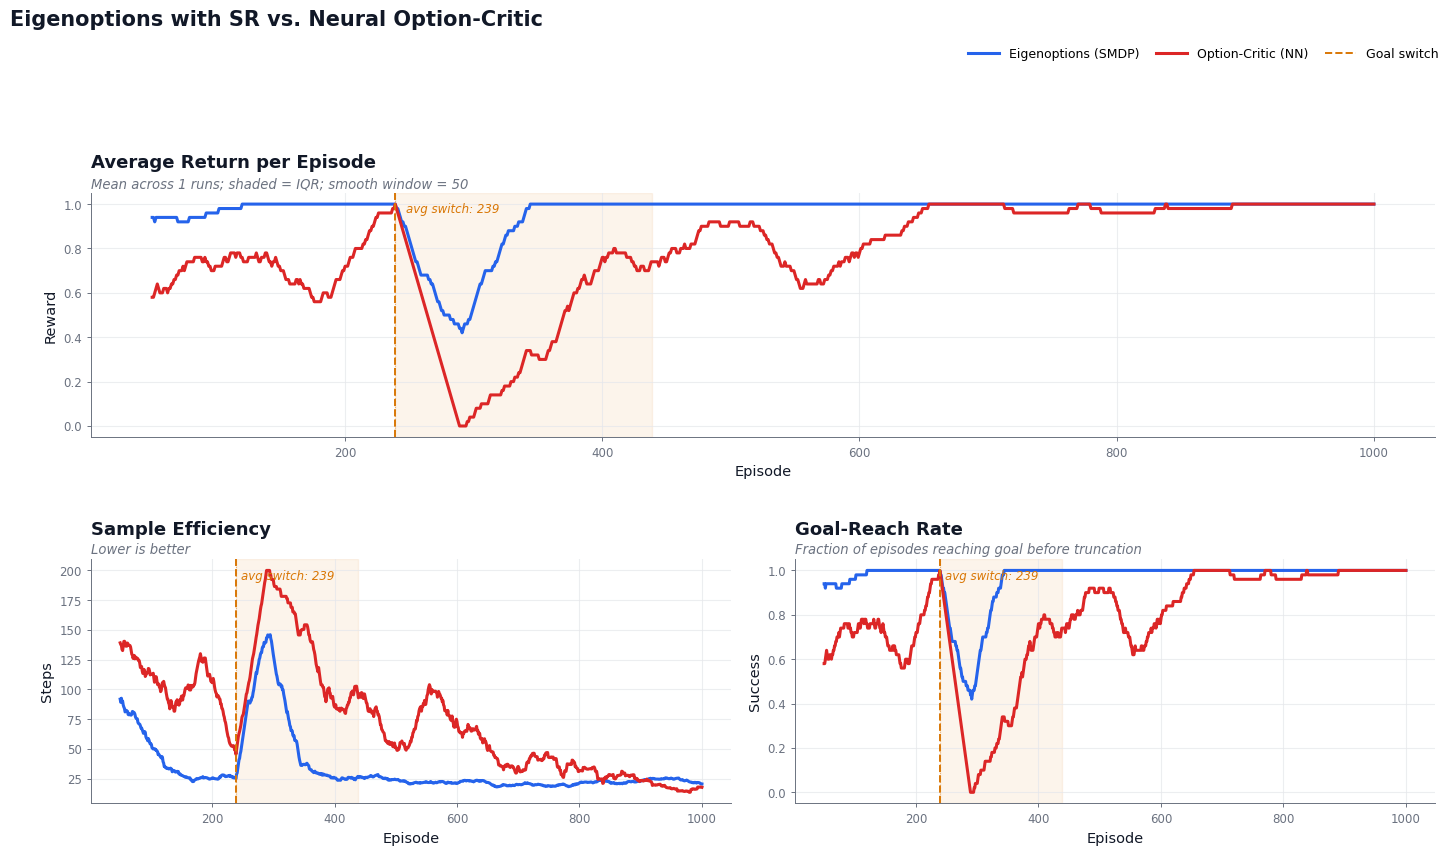

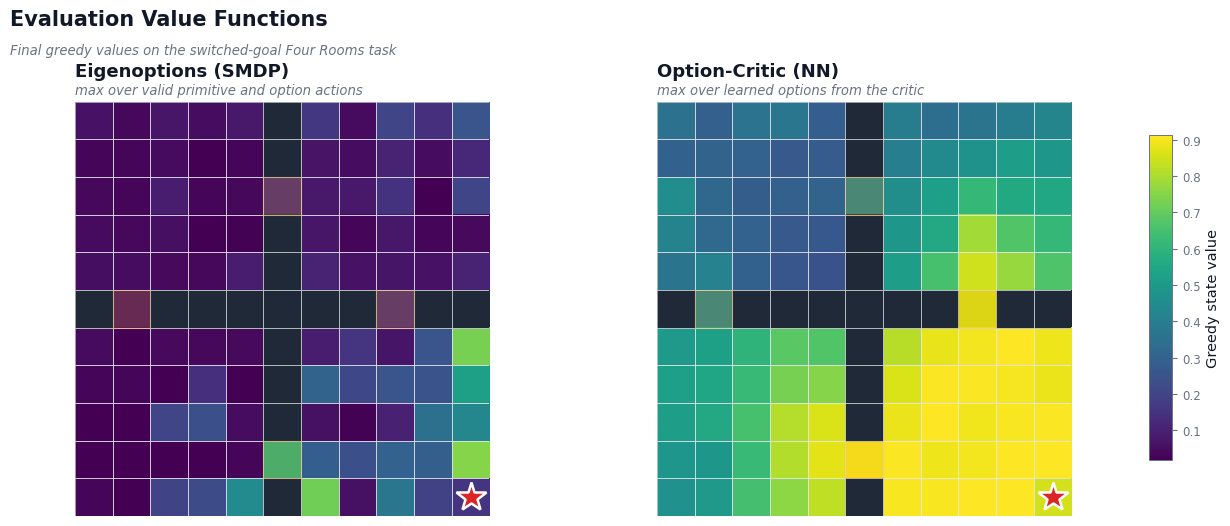

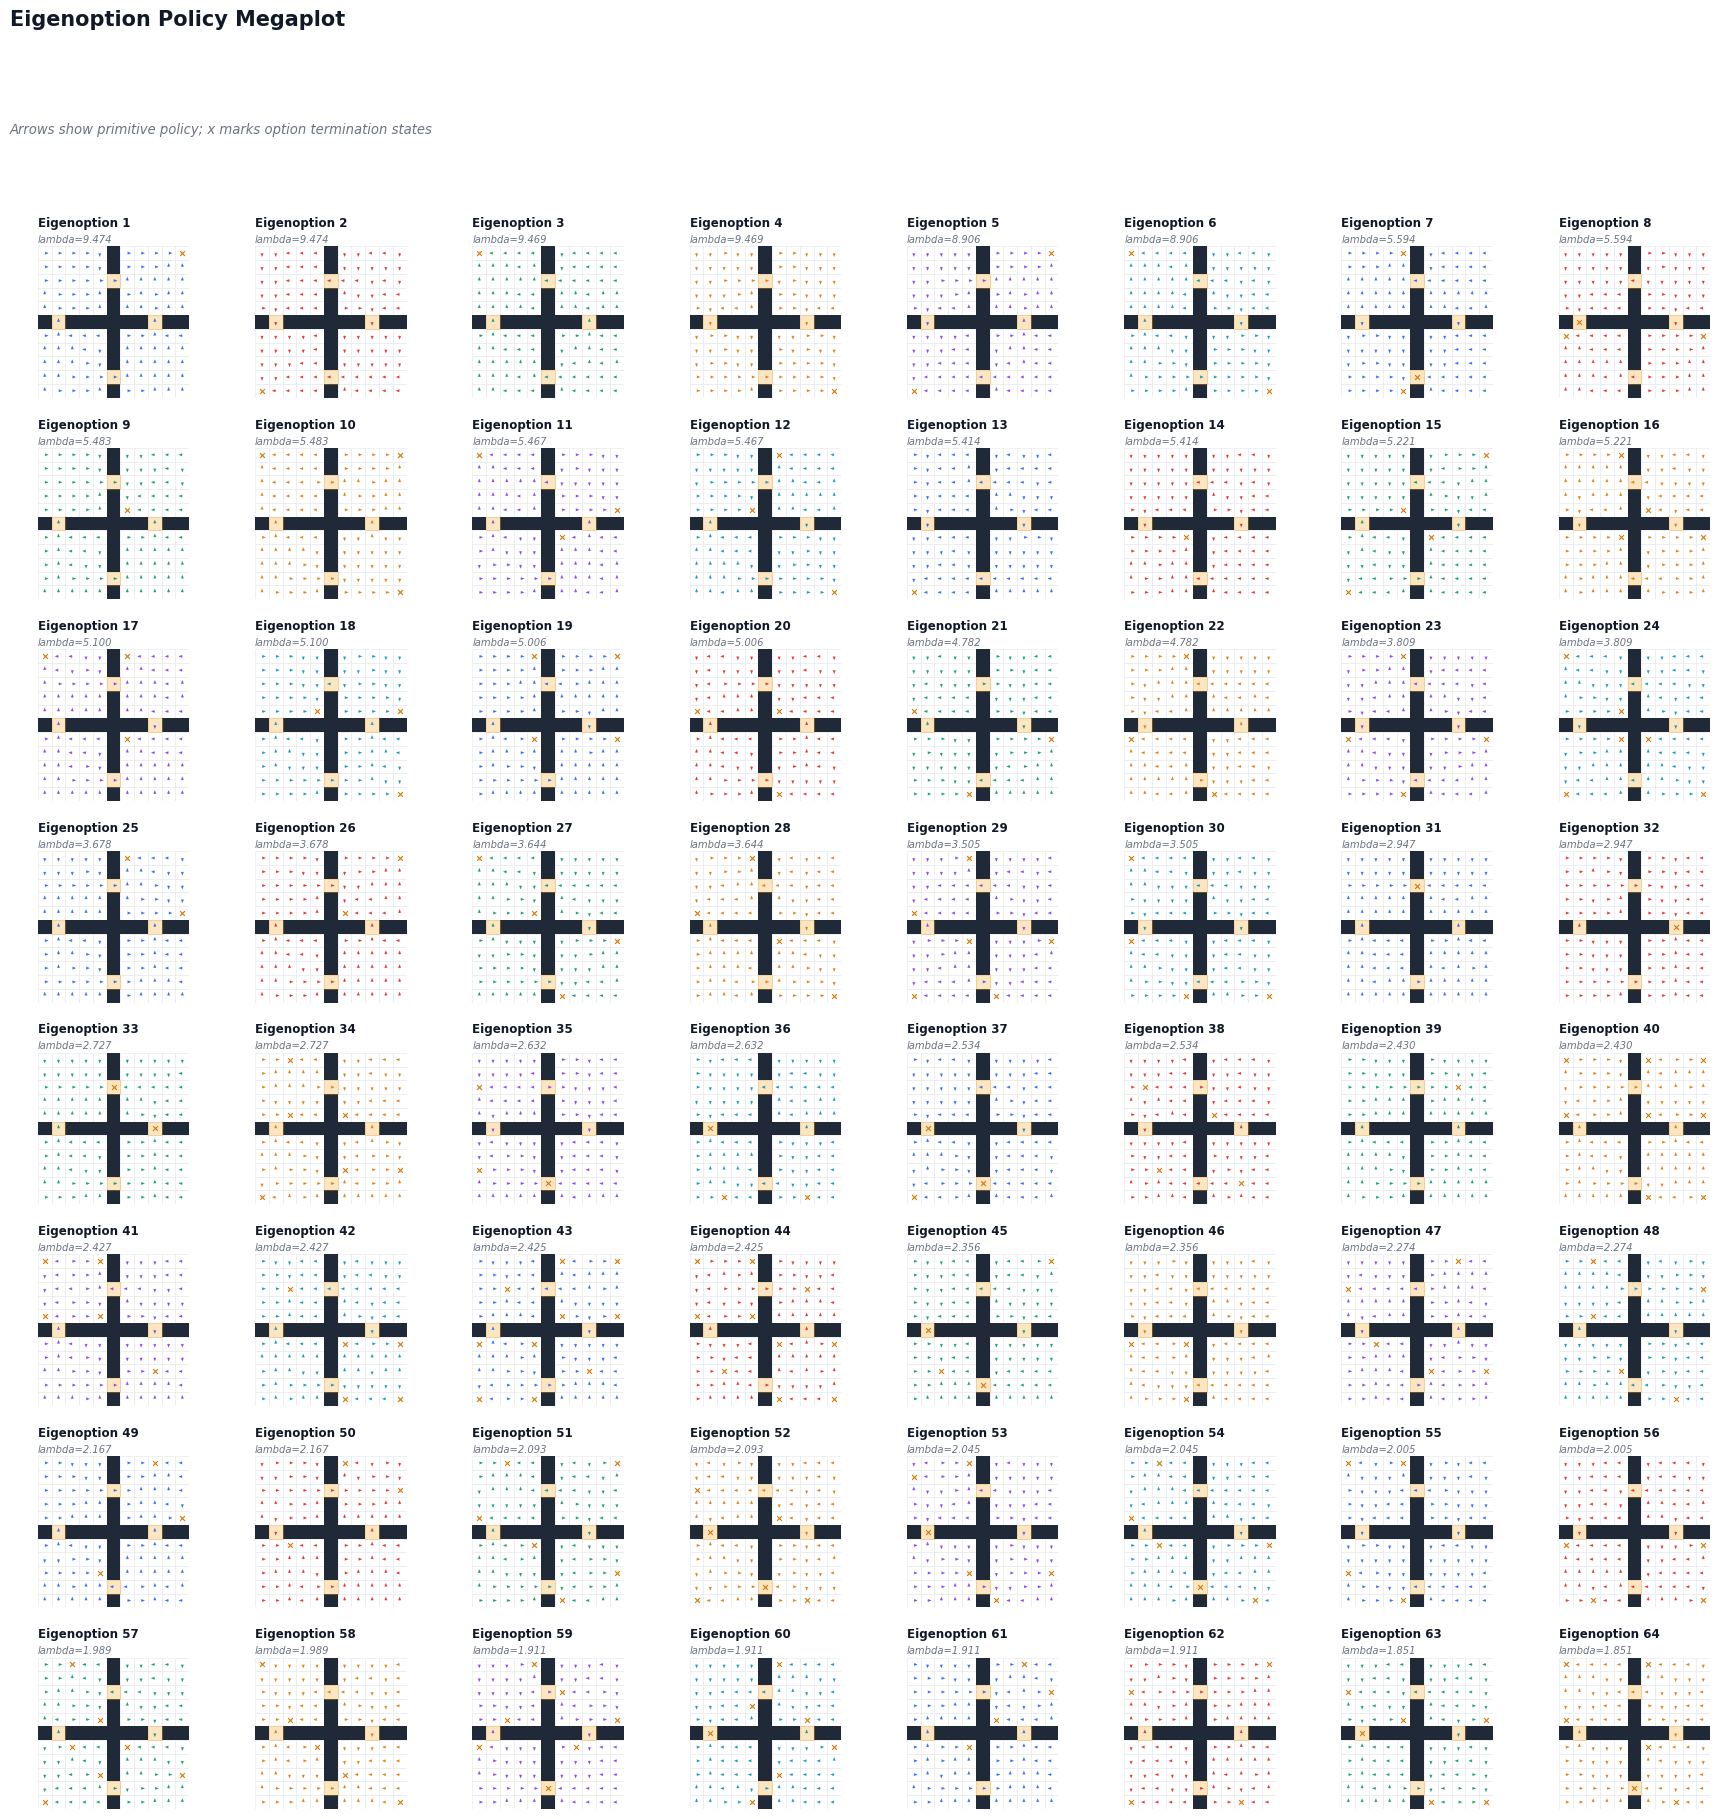

Saved 32 SR eigenvector surface plots to perfect_plots/sr_eigenvector_surfaces


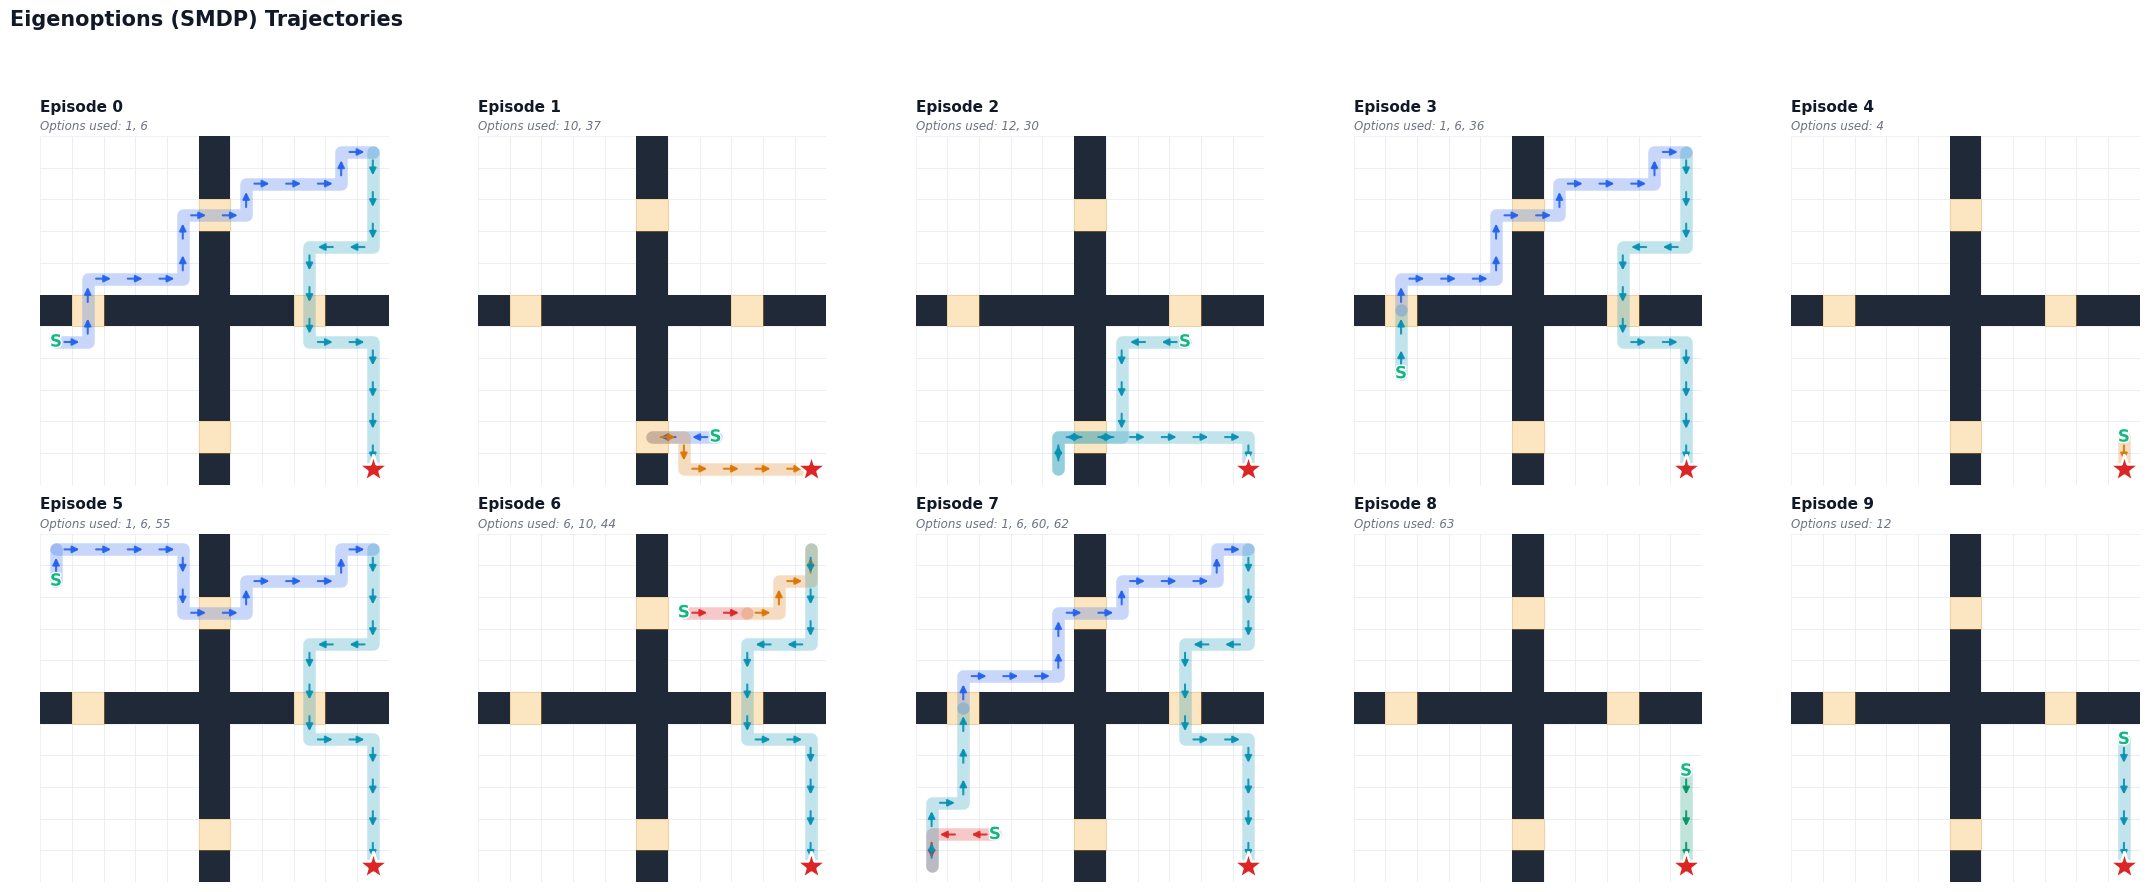

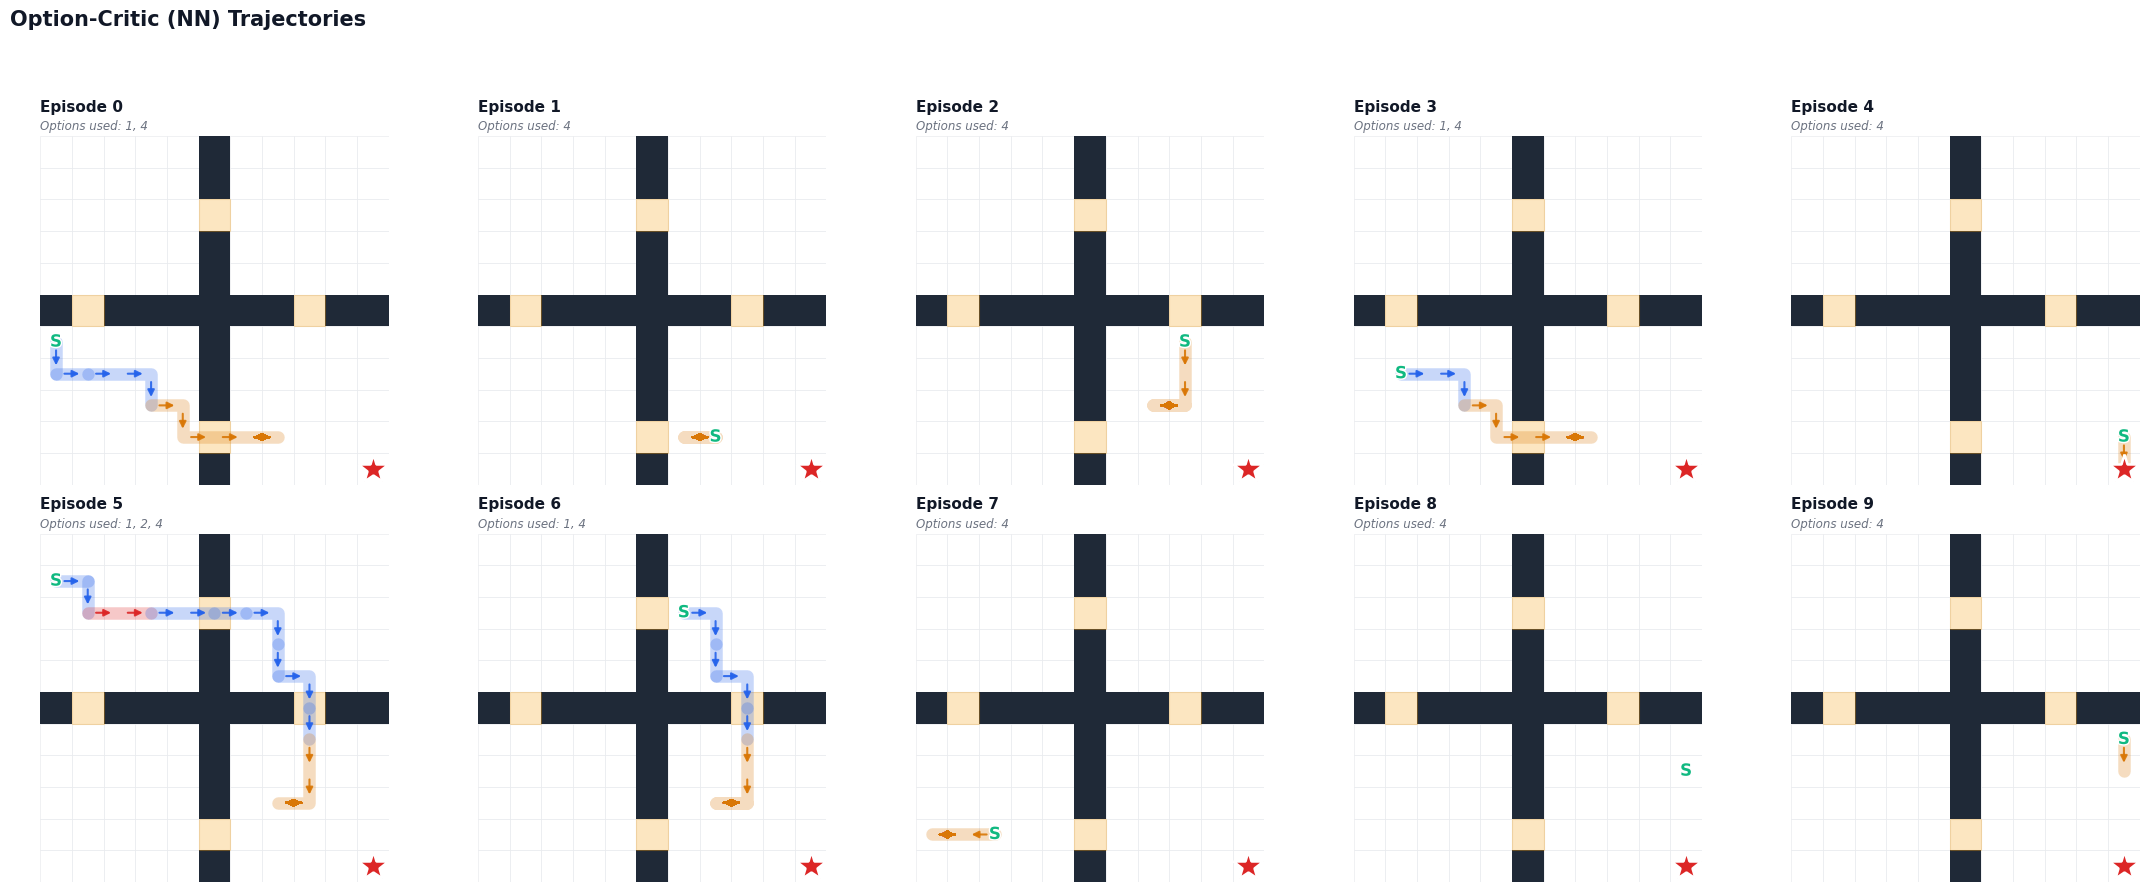

In [7]:
COLORS = {
    "eo": "#2563EB",
    "nn_oc": "#DC2626",
    "eo_fill": "#3B82F6",
    "nn_oc_fill": "#EF4444",
    "warn": "#D97706",
    "text": "#111827",
    "text_muted": "#6B7280",
    "background": "#FFFFFF",
    "grid": "#E5E7EB",
    "floor": "#FFFFFF",
    "wall": "#1F2937",
    "goal_switch": "#DC2626",
    "doorway": "#F59E0B",
    "start": "#10B981",
    "primitive": "#9CA3AF",
}
OPTION_CMAP = ["#2563EB", "#DC2626", "#059669", "#D97706", "#7C3AED", "#0891B2"]

FONT = {
    "title": {"size": 13, "weight": "bold", "color": COLORS["text"]},
    "subtitle": {"size": 9.5, "style": "italic", "color": COLORS["text_muted"]},
    "axis": {"size": 10.5, "weight": "medium", "color": COLORS["text"]},
    "tick": {"size": 8.5},
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": COLORS["text_muted"],
    "axes.linewidth": 0.7,
    "axes.facecolor": COLORS["background"],
    "figure.facecolor": COLORS["background"],
    "savefig.facecolor": COLORS["background"],
    "savefig.dpi": 180,
    "axes.unicode_minus": False,
    "legend.frameon": False,
})


def style_axes(ax, grid=True, spines=("left", "bottom")):
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(s in spines)
        if s in spines:
            ax.spines[s].set_color(COLORS["text_muted"])
    ax.tick_params(
        colors=COLORS["text_muted"], which="both", length=3, width=0.7,
        labelsize=FONT["tick"]["size"],
    )
    if grid:
        ax.grid(True, color=COLORS["grid"], alpha=0.7, linewidth=0.8, linestyle="-")
        ax.set_axisbelow(True)
    else:
        ax.grid(False)
    return ax


def set_title(ax, title, subtitle=None, size=None, subtitle_size=None, pad=None):
    title_size = size or FONT["title"]["size"]
    title_pad = pad if pad is not None else (18 if subtitle else 8)
    ax.set_title(
        title, loc="left", pad=title_pad,
        fontsize=title_size,
        fontweight=FONT["title"]["weight"],
        color=FONT["title"]["color"],
    )
    if subtitle:
        ax.text(
            0.0, 1.01, subtitle, transform=ax.transAxes,
            fontsize=subtitle_size or FONT["subtitle"]["size"],
            color=FONT["subtitle"]["color"],
            style=FONT["subtitle"]["style"], ha="left", va="bottom",
            clip_on=False,
        )


def fig_title(fig, title, subtitle=None, y=0.985):
    fig.suptitle(
        title, x=0.02, y=y, ha="left", va="top",
        fontsize=FONT["title"]["size"] + 2,
        fontweight=FONT["title"]["weight"],
        color=FONT["title"]["color"],
    )
    if subtitle:
        fig.text(
            0.02, y - 0.06, subtitle, ha="left", va="top",
            fontsize=FONT["subtitle"]["size"],
            color=FONT["subtitle"]["color"],
            style=FONT["subtitle"]["style"],
        )


def show_or_close(fig, show=True):
    if show and "agg" not in plt.get_backend().lower():
        plt.show()
    else:
        plt.close(fig)


def save_and_show(fig, output_path, rect=(0.02, 0.03, 0.98, 0.92), h_pad=2.0, w_pad=1.2, show=True):
    fig.tight_layout(rect=rect, h_pad=h_pad, w_pad=w_pad)
    fig.savefig(output_path, bbox_inches="tight", dpi=180)
    show_or_close(fig, show=show)


def rolling_avg(data, w):
    if len(data) < w:
        return np.array([])
    return np.convolve(data, np.ones(w) / w, mode="valid")


def smooth_runs(runs, w):
    arr = np.asarray(runs)
    smoothed = np.array([rolling_avg(arr[i], w) for i in range(arr.shape[0])])
    mean = smoothed.mean(axis=0)
    lo = np.percentile(smoothed, 25, axis=0)
    hi = np.percentile(smoothed, 75, axis=0)
    return mean, lo, hi


def draw_env_grid(ax, env, draw_doorways=True):
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            if (r, c) not in env.walls:
                ax.add_patch(plt.Rectangle(
                    (c - 0.5, env.grid_size - 1 - r - 0.5), 1, 1,
                    facecolor=COLORS["floor"], edgecolor=COLORS["grid"],
                    linewidth=0.4, zorder=1,
                ))
    for (r, c) in env.walls:
        ax.add_patch(plt.Rectangle(
            (c - 0.5, env.grid_size - 1 - r - 0.5), 1, 1,
            facecolor=COLORS["wall"], edgecolor="none", zorder=2,
        ))
    if draw_doorways:
        for (r, c) in env.doorway_list:
            ax.add_patch(plt.Rectangle(
                (c - 0.5, env.grid_size - 1 - r - 0.5), 1, 1,
                facecolor=COLORS["doorway"], alpha=0.25,
                edgecolor=COLORS["doorway"], linewidth=0.8, zorder=3,
            ))
    ax.set_xlim(-0.5, env.grid_size - 0.5)
    ax.set_ylim(-0.5, env.grid_size - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.set_facecolor(COLORS["background"])
    return ax


def draw_grid_overlay(ax, env, draw_doorways=True):
    for r in range(env.grid_size):
        for c in range(env.grid_size):
            x = c - 0.5
            y = env.grid_size - 1 - r - 0.5
            is_wall = (r, c) in env.walls
            ax.add_patch(plt.Rectangle(
                (x, y), 1, 1,
                facecolor=COLORS["wall"] if is_wall else "none",
                edgecolor=COLORS["grid"], linewidth=0.45,
                zorder=5 if is_wall else 4,
            ))
    if draw_doorways:
        for (r, c) in env.doorway_list:
            ax.add_patch(plt.Rectangle(
                (c - 0.5, env.grid_size - 1 - r - 0.5), 1, 1,
                facecolor=COLORS["doorway"], alpha=0.18,
                edgecolor=COLORS["doorway"], linewidth=1.0, zorder=6,
            ))
    ax.set_xlim(-0.5, env.grid_size - 0.5)
    ax.set_ylim(-0.5, env.grid_size - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    return ax


def mark_goal(ax, env, color=None, label=None, marker="*"):
    gr, gc = env.goal_state
    color = color or COLORS["goal_switch"]
    ax.plot(
        gc, env.grid_size - 1 - gr, marker, markersize=22, color=color,
        markeredgecolor="white", markeredgewidth=1.8, zorder=12,
        label=label,
    )


def state_values_to_grid(env, values, fill_value=np.nan):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    if values.shape[0] < env.num_states:
        raise ValueError(f"Expected at least {env.num_states} state values, got {values.shape[0]}")
    grid = np.full((env.grid_size, env.grid_size), fill_value, dtype=np.float64)
    for s_idx, (r, c) in env.idx_to_state.items():
        grid[r, c] = values[s_idx]
    return grid


def grid_values_for_display(env, values):
    return np.flipud(state_values_to_grid(env, values))


def smdp_value_function(q_table, options, env):
    q_table = np.asarray(q_table, dtype=np.float64)
    values = np.full(env.num_states, np.nan, dtype=np.float64)
    for s_idx in range(env.num_states):
        valid_actions = [0, 1, 2, 3]
        for opt_idx, opt in enumerate(options):
            if opt.can_initiate(s_idx, env):
                valid_actions.append(4 + opt_idx)
        valid_actions = [a for a in valid_actions if a < q_table.shape[1]]
        if valid_actions:
            values[s_idx] = np.max(q_table[s_idx, valid_actions])
    return values


def nn_oc_value_function(results, env, device="cpu"):
    q_table = None
    if results.get("nn_oc_snapshots"):
        q_table = results["nn_oc_snapshots"][-1].get("final")
    if q_table is None and "final_nn_oc_critic" in results:
        q_table = net_to_qtable(results["final_nn_oc_critic"], env, torch.device(device))
    if q_table is None:
        raise KeyError("No final Option-Critic critic values are available for plotting.")
    return np.max(np.asarray(q_table, dtype=np.float64), axis=1)


def plot_grid_heatmap(ax, env, values, title, subtitle, vmin=None, vmax=None, cmap="viridis"):
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(COLORS["wall"])
    masked = np.ma.masked_invalid(grid_values_for_display(env, values))
    im = ax.imshow(
        masked, origin="lower",
        extent=(-0.5, env.grid_size - 0.5, -0.5, env.grid_size - 0.5),
        cmap=cmap_obj, vmin=vmin, vmax=vmax, interpolation="nearest", zorder=0,
    )
    draw_grid_overlay(ax, env)
    mark_goal(ax, env, color=COLORS["goal_switch"])
    set_title(ax, title, subtitle)
    return im


def plot_value_heatmaps(results, env, output_path):
    eo_values = smdp_value_function(results["final_eo_q"], results["smdp_options"], env)
    nn_oc_values = nn_oc_value_function(results, env)
    finite = np.concatenate([eo_values[np.isfinite(eo_values)], nn_oc_values[np.isfinite(nn_oc_values)]])
    vmin, vmax = np.percentile(finite, [2, 98]) if finite.size else (0.0, 1.0)
    if np.isclose(vmin, vmax):
        vmin -= 0.5
        vmax += 0.5

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.6), constrained_layout=False)
    im = plot_grid_heatmap(
        axes[0], env, eo_values,
        "Eigenoptions (SMDP)", "max over valid primitive and option actions",
        vmin=vmin, vmax=vmax,
    )
    plot_grid_heatmap(
        axes[1], env, nn_oc_values,
        "Option-Critic (NN)", "max over learned options from the critic",
        vmin=vmin, vmax=vmax,
    )
    cax = fig.add_axes([0.91, 0.18, 0.018, 0.58])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Greedy state value", fontdict=FONT["axis"])
    cbar.ax.tick_params(labelsize=FONT["tick"]["size"], colors=COLORS["text_muted"])
    fig_title(fig, "Evaluation Value Functions", "Final greedy values on the switched-goal Four Rooms task")
    fig.subplots_adjust(left=0.04, right=0.88, bottom=0.08, top=0.82, wspace=0.18)
    fig.savefig(output_path, bbox_inches="tight", dpi=180)
    show_or_close(fig)


def plot_training_dynamics(results, output_dir, snapshot_early_offset):
    window = 50
    switch_episodes = results["switch_episodes"]
    avg_switch = int(np.mean(switch_episodes))

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=False)
    gs = axes[0, 0].get_gridspec()
    for ax in axes.flat:
        ax.remove()
    ax_r = fig.add_subplot(gs[0, :])
    ax_s = fig.add_subplot(gs[1, 0])
    ax_su = fig.add_subplot(gs[1, 1])

    def plot_band(ax, eo_runs, nn_oc_runs, ylabel, title, subtitle):
        eo_m, eo_lo, eo_hi = smooth_runs(eo_runs, window)
        nn_oc_m, nn_oc_lo, nn_oc_hi = smooth_runs(nn_oc_runs, window)
        x = np.arange(len(eo_m)) + window
        ax.fill_between(x, eo_lo, eo_hi, color=COLORS["eo_fill"], alpha=0.18, lw=0)
        ax.fill_between(x, nn_oc_lo, nn_oc_hi, color=COLORS["nn_oc_fill"], alpha=0.18, lw=0)
        ax.plot(x, eo_m, color=COLORS["eo"], lw=2.2, label="Eigenoptions (SMDP)")
        ax.plot(x, nn_oc_m, color=COLORS["nn_oc"], lw=2.2, label="Option-Critic (NN)")
        ax.axvspan(avg_switch, avg_switch + snapshot_early_offset, color=COLORS["warn"], alpha=0.08, zorder=0)
        ax.axvline(avg_switch, color=COLORS["warn"], lw=1.4, ls="--", zorder=5)
        ax.text(
            avg_switch + 8, 0.96, f"avg switch: {avg_switch}",
            transform=ax.get_xaxis_transform(), color=COLORS["warn"],
            fontsize=8.5, style="italic", va="top", ha="left",
        )
        for sw in switch_episodes:
            ax.axvline(sw, color=COLORS["warn"], lw=0.8, ls=":", alpha=0.5, zorder=4)
        style_axes(ax)
        set_title(ax, title, subtitle)
        ax.set_xlabel("Episode", fontdict=FONT["axis"])
        ax.set_ylabel(ylabel, fontdict=FONT["axis"])

    n_runs = len(results["eo_rewards"])
    plot_band(
        ax_r, results["eo_rewards"], results["nn_oc_rewards"],
        "Reward", "Average Return per Episode",
        f"Mean across {n_runs} runs; shaded = IQR; smooth window = {window}",
    )
    plot_band(ax_s, results["eo_steps"], results["nn_oc_steps"], "Steps", "Sample Efficiency", "Lower is better")
    plot_band(
        ax_su, results["eo_success"], results["nn_oc_success"],
        "Success", "Goal-Reach Rate", "Fraction of episodes reaching goal before truncation",
    )

    legend_handles = [
        plt.Line2D([0], [0], color=COLORS["eo"], lw=2.2, label="Eigenoptions (SMDP)"),
        plt.Line2D([0], [0], color=COLORS["nn_oc"], lw=2.2, label="Option-Critic (NN)"),
        plt.Line2D([0], [0], color=COLORS["warn"], lw=1.4, ls="--", label="Goal switch"),
    ]
    fig.legend(
        handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.955),
        ncol=3, prop={"size": 9}, handlelength=2.5, columnspacing=1.3,
    )
    fig_title(fig, "Eigenoptions with SR vs. Neural Option-Critic")
    save_and_show(fig, output_dir / "01_training_dynamics.png", rect=(0.03, 0.04, 0.98, 0.88), h_pad=3.0)


def get_action_color(action):
    if action < 4:
        return COLORS["primitive"]
    return OPTION_CMAP[(action - 4) % len(OPTION_CMAP)]


def plot_eigenoption_policy(ax, option, env, color):
    draw_env_grid(ax, env, draw_doorways=True)
    deltas = {
        0: (0.0, 0.28),
        1: (0.28, 0.0),
        2: (0.0, -0.28),
        3: (-0.28, 0.0),
    }
    xs, ys, us, vs = [], [], [], []
    term_x, term_y = [], []
    for s_idx, (r, c) in env.idx_to_state.items():
        action = int(option.pi[s_idx])
        x = c
        y = env.grid_size - 1 - r
        if action == 4:
            term_x.append(x)
            term_y.append(y)
        elif action in deltas:
            dx, dy = deltas[action]
            xs.append(x)
            ys.append(y)
            us.append(dx)
            vs.append(dy)
    if xs:
        ax.quiver(
            xs, ys, us, vs, angles="xy", scale_units="xy", scale=1,
            color=color, width=0.006, headwidth=3.6, headlength=4.4,
            headaxislength=3.8, alpha=0.9, zorder=6,
        )
    if term_x:
        ax.scatter(term_x, term_y, marker="x", s=12, color=COLORS["warn"], linewidths=0.8, zorder=7)


def plot_eigenoption_megaplot(options, env, output_path, max_cols=8):
    n_opts = len(options)
    if n_opts == 0:
        return
    cols = min(max_cols, n_opts)
    rows = math.ceil(n_opts / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.25, rows * 2.35), constrained_layout=False)
    axes = np.asarray(axes).reshape(-1)

    for idx, option in enumerate(options):
        ax = axes[idx]
        color = OPTION_CMAP[idx % len(OPTION_CMAP)]
        plot_eigenoption_policy(ax, option, env, color)
        set_title(
            ax, f"Eigenoption {idx + 1}", f"lambda={option.eigenvalue:.3f}",
            size=8.5, subtitle_size=7.2, pad=14,
        )
    for ax in axes[n_opts:]:
        ax.axis("off")

    fig_title(fig, "Eigenoption Policy Megaplot", "Arrows show primitive policy; x marks option termination states")
    save_and_show(fig, output_path, rect=(0.01, 0.02, 0.99, 0.90), h_pad=1.9, w_pad=0.3)


def plot_episode_trajectories(trajectories, env, start_ep, end_ep, title_prefix, output_path):
    episodes_to_plot = [ep for ep in range(start_ep, end_ep + 1) if ep in trajectories]
    n_eps = len(episodes_to_plot)
    if n_eps == 0:
        return

    cols = min(5, n_eps)
    rows = math.ceil(n_eps / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4.6), constrained_layout=False)
    if n_eps == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, ep in enumerate(episodes_to_plot):
        ax = axes[idx]
        traj = trajectories[ep]

        if not traj:
            ax.axis("off")
            continue

        draw_env_grid(ax, env)
        used_options = sorted(set(step["high_level_action"] for step in traj if step["high_level_action"] >= 4))
        if used_options:
            opt_strs = [str(act - 4 + 1) for act in used_options]
            subtitle = f"Options used: {', '.join(opt_strs)}"
        else:
            subtitle = "Primitives only"
        set_title(ax, f"Episode {ep}", subtitle, size=11, subtitle_size=8.5)

        start_state = traj[0]["transitions"][0][0]
        ax.text(
            start_state[1], env.grid_size - 1 - start_state[0], "S",
            color=COLORS["start"], weight="bold", fontsize=12,
            ha="center", va="center", zorder=6,
            path_effects=[path_effects.withStroke(linewidth=2, foreground="white")],
        )

        mark_goal(ax, env, color=COLORS["goal_switch"])

        for step in traj:
            action = step["high_level_action"]
            color = get_action_color(action)

            if step["transitions"]:
                path_x = [step["transitions"][0][0][1]]
                path_y = [env.grid_size - 1 - step["transitions"][0][0][0]]

                for (state, next_state) in step["transitions"]:
                    path_x.append(next_state[1])
                    path_y.append(env.grid_size - 1 - next_state[0])

                ax.plot(
                    path_x, path_y, color=color, linewidth=9, alpha=0.25,
                    solid_capstyle="round", solid_joinstyle="round", zorder=3,
                )

            for (state, next_state) in step["transitions"]:
                x1, y1 = state[1], env.grid_size - 1 - state[0]
                x2, y2 = next_state[1], env.grid_size - 1 - next_state[0]

                if x1 != x2 or y1 != y2:
                    ax.add_patch(mpatches.FancyArrowPatch(
                        (x1, y1), (x2, y2),
                        color=color, mutation_scale=10, arrowstyle="-|>",
                        shrinkA=6, shrinkB=6, linewidth=1.5, zorder=4,
                        alpha=0.9,
                    ))

    for i in range(n_eps, len(axes)):
        axes[i].axis("off")

    fig_title(fig, f"{title_prefix} Trajectories")
    save_and_show(fig, output_path, rect=(0.01, 0.02, 0.99, 0.93), h_pad=2.4, w_pad=1.0)


def get_sr_eigenpairs_for_plots(results, env, hyperparams):
    if "sr_eigenvalues" in results and "sr_eigenvectors" in results:
        return results["sr_eigenvalues"], results["sr_eigenvectors"]
    m_sr = build_sr(env, hyperparams["sr_gamma"])
    eigenvalues, eigenvectors = decompose_sr(m_sr)
    results["sr_matrix"] = m_sr
    results["sr_eigenvalues"] = eigenvalues
    results["sr_eigenvectors"] = eigenvectors
    return eigenvalues, eigenvectors


def plot_sr_eigenvector_surfaces(eigenvectors, eigenvalues, env, first_eigenoption, num_vectors, output_dir):
    surface_dir = output_dir / "sr_eigenvector_surfaces"
    surface_dir.mkdir(exist_ok=True)
    start = int(first_eigenoption)
    end = min(start + int(num_vectors), len(eigenvectors))
    x = np.arange(env.grid_size)
    y = np.arange(env.grid_size)
    X, Y = np.meshgrid(x, y)
    saved_paths = []

    for eig_idx in range(start, end):
        Z = np.ma.masked_invalid(state_values_to_grid(env, eigenvectors[eig_idx]))
        fig = plt.figure(figsize=(7.2, 5.8), constrained_layout=False)
        ax = fig.add_subplot(111, projection="3d")
        surf = ax.plot_surface(X, Y, Z, cmap="jet", linewidth=0, antialiased=True)
        ax.set_xlabel("grid X", labelpad=8)
        ax.set_ylabel("grid Y", labelpad=8)
        ax.set_zlabel("eigenvector value", labelpad=14)
        ax.text2D(
            -0.08, 0.52, "eigenvector value", transform=ax.transAxes,
            rotation=90, va="center", ha="center", clip_on=False,
            fontsize=FONT["axis"]["size"], color=FONT["axis"]["color"],
        )
        ax.set_title(
            f"SR Eigenvector {eig_idx} (lambda={eigenvalues[eig_idx]:.4f})",
            pad=18, fontsize=FONT["title"]["size"], fontweight=FONT["title"]["weight"],
            color=FONT["title"]["color"],
        )
        ax.view_init(elev=28, azim=-135)
        cbar = fig.colorbar(surf, ax=ax, shrink=0.68, pad=0.12)
        cbar.set_label("eigenvector value")
        cbar.ax.tick_params(labelsize=FONT["tick"]["size"])
        output_path = surface_dir / f"04_sr_eigenvector_surface_{eig_idx:02d}.png"
        fig.subplots_adjust(left=0.08, right=0.84, bottom=0.06, top=0.88)
        fig.savefig(output_path, bbox_inches="tight", dpi=180)
        plt.close(fig)
        saved_paths.append(output_path)
    return saved_paths


# Execution of plotting
plot_training_dynamics(experiment_results, OUTPUT_DIR, HYPERPARAMS["snapshot_early_offset"])

plot_value_heatmaps(experiment_results, env_eval, OUTPUT_DIR / "02_value_function_heatmaps.png")

plot_eigenoption_megaplot(
    experiment_results["smdp_options"], env_eval,
    OUTPUT_DIR / "03_eigenoption_policy_megaplot.png",
)

sr_eigenvalues, sr_eigenvectors = get_sr_eigenpairs_for_plots(experiment_results, env_eval, HYPERPARAMS)
surface_paths = plot_sr_eigenvector_surfaces(
    sr_eigenvectors, sr_eigenvalues, env_eval,
    HYPERPARAMS["first_eigenoption"], HYPERPARAMS["eigenpurpose_k"], OUTPUT_DIR,
)
print(f"Saved {len(surface_paths)} SR eigenvector surface plots to {OUTPUT_DIR / 'sr_eigenvector_surfaces'}")

plot_episode_trajectories(
    eo_eval_trajectories, env_eval, 0, 9,
    "Eigenoptions (SMDP)", OUTPUT_DIR / "06_eigenoptions_trajectories.png",
)

plot_episode_trajectories(
    nn_oc_eval_trajectories, env_eval, 0, 9,
    "Option-Critic (NN)", OUTPUT_DIR / "07_nn_oc_trajectories.png",
)
